In [208]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import ttest_ind, levene
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing as ETS

np.random.seed(42)

In [209]:
df = pd.read_csv("FB_GOOG_Historical_Prices_2015_2016.csv")

In [210]:
df.head()

,date,FB,GOOG
0,2015-01-02,78.45,524.81
1,2015-01-05,77.19,513.87
2,2015-01-06,76.15,501.96
3,2015-01-07,76.15,501.10
4,2015-01-08,78.18,502.68


In [211]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 504 entries, 0 to 503
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    504 non-null    object 
 1   FB      504 non-null    float64
 2   GOOG    504 non-null    float64
dtypes: float64(2), object(1)
memory usage: 11.9+ KB


In [212]:
# changing date type to datetime
df["date"] = pd.to_datetime(df["date"], format="%Y-%m-%d")

In [213]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 504 entries, 0 to 503
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    504 non-null    datetime64[ns]
 1   FB      504 non-null    float64       
 2   GOOG    504 non-null    float64       
dtypes: datetime64[ns](1), float64(2)
memory usage: 11.9 KB


In [214]:
df.head()

,date,FB,GOOG
0,2015-01-02,78.45,524.81
1,2015-01-05,77.19,513.87
2,2015-01-06,76.15,501.96
3,2015-01-07,76.15,501.10
4,2015-01-08,78.18,502.68


## Task 1

In [215]:
fb_daily_returns = df["FB"].shift(-1) / df["FB"] - 1
goog_daily_returns = df["GOOG"].shift(-1) / df["GOOG"] - 1

fb_daily_mean = fb_daily_returns.mean()
fb_daily_std = fb_daily_returns.std()
print(f"FB daily return mean: {fb_daily_mean} and standard deviation: {fb_daily_std}")

goog_daily_mean = goog_daily_returns.mean()
goog_daily_std = goog_daily_returns.std()
print(f"GOOG daily return mean: {goog_daily_mean} and standard deviation: {goog_daily_std}")

FB daily return mean: 0.0009045706094875624 and standard deviation: 0.017050472043500107
GOOG daily return mean: 0.0008903930946407605 and standard deviation: 0.015894471452196062


## Task 2

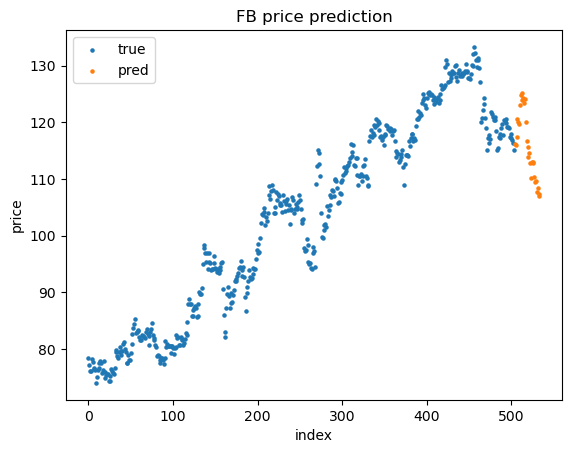

In [216]:
days = 30

fb_returns_pred = np.random.normal(
    loc=fb_daily_mean, 
    scale=fb_daily_std, 
    size=days
)

fb_last_price = df["FB"].iloc[-1]
fb_price_pred = fb_last_price * np.cumprod(1 + fb_returns_pred)

idx_start = df.index[-1] + 1
idx_end = idx_start + days
pred_index = np.arange(idx_start, idx_end)

plt.scatter(df.index, df["FB"], s=5)
plt.scatter(pred_index, fb_price_pred, s=5)
plt.legend(["true", "pred"])
plt.xlabel("index")
plt.ylabel("price")
plt.title("FB price prediction")
plt.show()


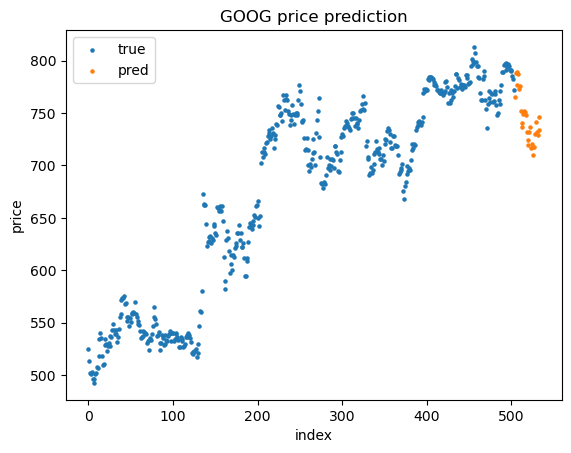

In [217]:
goog_returns_pred = np.random.normal(
    loc=goog_daily_mean, 
    scale=goog_daily_std, 
    size=days
)

goog_last_price = df["GOOG"].iloc[-1]
goog_price_pred = goog_last_price * np.cumprod(1 + goog_returns_pred)

plt.scatter(df.index, df["GOOG"], s=5)
plt.scatter(pred_index, goog_price_pred, s=5)
plt.legend(["true", "pred"])
plt.xlabel("index")
plt.ylabel("price")
plt.title("GOOG price prediction")
plt.show()

## Task 3

In [218]:
def predict_price(mean, std, days, last_price):
    returns_pred = np.random.normal(loc=mean, scale=std, size=days)
    price_pred = last_price * np.cumprod(1 + returns_pred)
    return price_pred

In [219]:
days = 60
n = 1000
goog_last_price = df["GOOG"].iloc[-1]
exp_sum = 0

for i in range(n):
    preds = predict_price(goog_daily_mean, goog_daily_std, days, goog_last_price)
    pred = preds[-1]
    exp_sum += pred

avg_price = exp_sum / n

print(f"Average GOOG ending price after {days} days is {avg_price}")

Average GOOG ending price after 60 days is 814.6151436631379


## Task 4

In [220]:
days = 30
n = 1000
fb_last_price = df["FB"].iloc[-1]
exceed_count = 0

EXCEED_THRESHOLD = 150

for i in range(n):
    preds = predict_price(fb_daily_mean, fb_daily_std, days, fb_last_price)
    pred = preds[-1]
    if pred > EXCEED_THRESHOLD:
        exceed_count += 1

exceed_prob = exceed_count / n

print(f"Probability of FB price exceeding {EXCEED_THRESHOLD} after {days} days is {exceed_prob:.5f}")

Probability of FB price exceeding 150 after 30 days is 0.00700


## Task 5

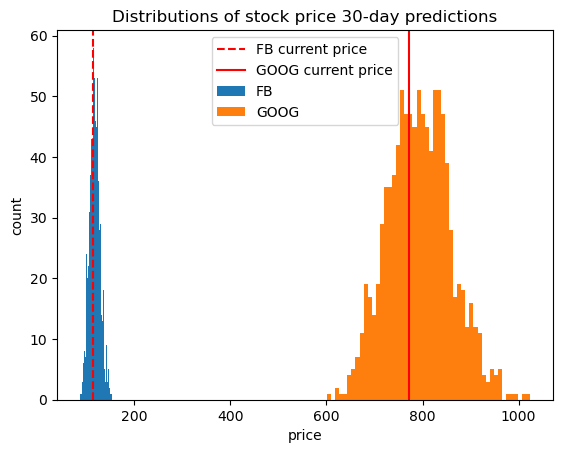

In [221]:
days = 30
n = 1000

goog_last_price = df["GOOG"].iloc[-1]
goog_preds = []

for i in range(n):
    preds = predict_price(goog_daily_mean, goog_daily_std, days, goog_last_price)
    pred = preds[-1]
    goog_preds.append(pred)

    
fb_last_price = df["FB"].iloc[-1]
fb_preds = []

for i in range(n):
    preds = predict_price(fb_daily_mean, fb_daily_std, days, fb_last_price)
    pred = preds[-1]
    fb_preds.append(pred)

plt.hist(fb_preds, bins=50)
plt.hist(goog_preds, bins=50)
plt.axline((fb_last_price, 0), (fb_last_price, 1), color="red", linestyle="--")
plt.axline((goog_last_price, 0), (goog_last_price, 1), color="red", linestyle="-")
plt.legend(["FB current price", "GOOG current price", "FB", "GOOG"])
plt.xlabel("price")
plt.ylabel("count")
plt.title(f"Distributions of stock price {days}-day predictions")
plt.show()

# higher volatility - GOOG
# potential upside - GOOG

## Task 6

In [222]:
target_power = 0.8
num_sim = 1000

max_days = len(fb_daily_returns) * 3

days = 100
while days < max_days:
    count_sig = 0
    
    for _ in range(num_sim):
        fb_sample = np.random.choice(fb_daily_returns, days, replace=True)
        goog_sample = np.random.choice(goog_daily_returns, days, replace=True)
        
        stat, p = ttest_ind(fb_sample, goog_sample)
        
        if p < 0.05:
            count_sig += 1
    
    power = count_sig / num_sim
    
    if power >= target_power:
        print(f"Required number of days: {days}")
        print(f"Achieved power: {power:.3f}")
        break
    days += 50
    print(f"Increasing sample size to {days}, power: {power:.3f}")
    
# couldn't find such a sample size
# with increasing sample size, prob of rejecting null hypothesis goes to 0
# so there is no statistical difference in daily returns

Increasing sample size to 150, power: 0.036
Increasing sample size to 200, power: 0.022
Increasing sample size to 250, power: 0.029
Increasing sample size to 300, power: 0.020
Increasing sample size to 350, power: 0.011
Increasing sample size to 400, power: 0.007
Increasing sample size to 450, power: 0.012
Increasing sample size to 500, power: 0.010
Increasing sample size to 550, power: 0.008
Increasing sample size to 600, power: 0.003
Increasing sample size to 650, power: 0.004
Increasing sample size to 700, power: 0.006
Increasing sample size to 750, power: 0.001
Increasing sample size to 800, power: 0.006
Increasing sample size to 850, power: 0.003
Increasing sample size to 900, power: 0.002
Increasing sample size to 950, power: 0.001
Increasing sample size to 1000, power: 0.001
Increasing sample size to 1050, power: 0.004
Increasing sample size to 1100, power: 0.001
Increasing sample size to 1150, power: 0.000
Increasing sample size to 1200, power: 0.002
Increasing sample size to 1

## Task 7

n=20, power=0.040
n=40, power=0.080
n=60, power=0.030
n=80, power=0.070
n=100, power=0.080
n=120, power=0.040
n=140, power=0.080
n=160, power=0.090
n=180, power=0.070
n=200, power=0.060
n=220, power=0.080
n=240, power=0.090
n=260, power=0.110
n=280, power=0.110
n=300, power=0.040
n=320, power=0.070
n=340, power=0.090
n=360, power=0.100
n=380, power=0.060
n=400, power=0.040
n=420, power=0.040
n=440, power=0.060
n=460, power=0.090
n=480, power=0.050
n=500, power=0.040
n=520, power=0.040
n=540, power=0.020
n=560, power=0.040
n=580, power=0.030
n=600, power=0.030
n=620, power=0.060
n=640, power=0.020
n=660, power=0.040
n=680, power=0.040
n=700, power=0.020
n=720, power=0.040
n=740, power=0.010
n=760, power=0.040
n=780, power=0.030
n=800, power=0.010
n=820, power=0.020
n=840, power=0.010
n=860, power=0.010
n=880, power=0.020
n=900, power=0.030
n=920, power=0.020
n=940, power=0.010
n=960, power=0.010
n=980, power=0.000
n=1000, power=0.010
n=1020, power=0.010
n=1040, power=0.010
n=1060, power

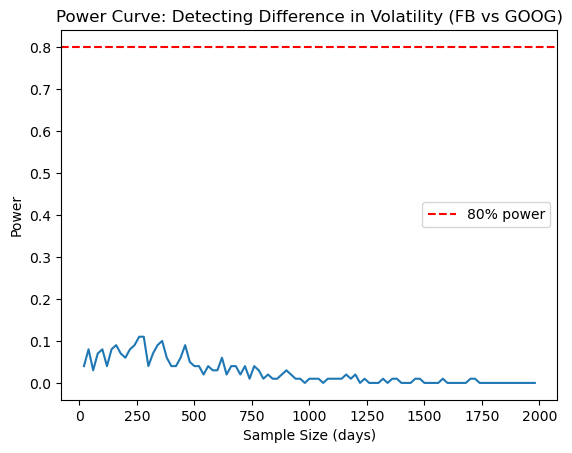

In [223]:
num_sim = 100
alpha = 0.05

sample_sizes = range(20, 2000, 20)
powers = []

for days in sample_sizes:
    count_reject = 0
    
    for _ in range(num_sim):
        fb_sample = np.random.choice(fb_daily_returns, days, replace=True)
        goog_sample = np.random.choice(goog_daily_returns, days, replace=True)
            
        stat, p = levene(fb_sample, goog_sample)
        if p < 0.05:
            count_reject += 1
    
    power = count_reject / num_sim
    powers.append(power)
    print(f"n={days}, power={power:.3f}")

plt.plot(sample_sizes, powers)
plt.axhline(0.8, color='red', linestyle='--', label='80% power')
plt.xlabel("Sample Size (days)")
plt.ylabel("Power")
plt.title("Power Curve: Detecting Difference in Volatility (FB vs GOOG)")
plt.legend()
plt.show()

# similarly to the previous task, with increasing sample size, the probability of rejecting the null hypothesis goes to 0, so there is no reason for rejecting the null hypothesis (volatility is not statistically different)

## Task 8

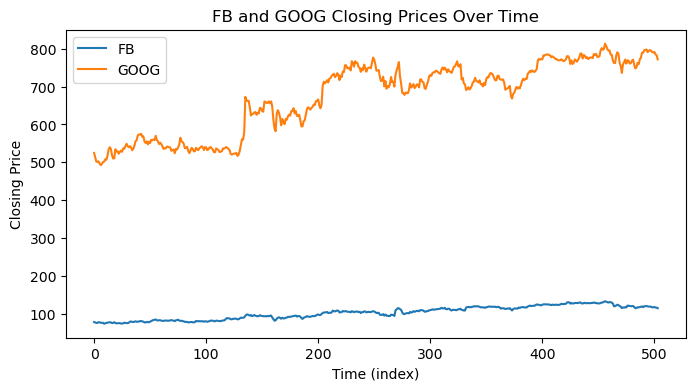

In [224]:
plt.figure(figsize=(8, 4))
plt.plot(df.index, df['FB'], label='FB')
plt.plot(df.index, df['GOOG'], label='GOOG')
plt.xlabel('Time (index)')
plt.ylabel('Closing Price')
plt.title('FB and GOOG Closing Prices Over Time')
plt.legend()
plt.show()

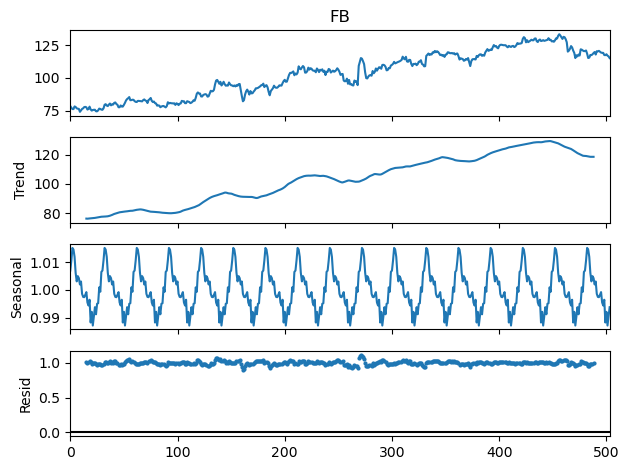

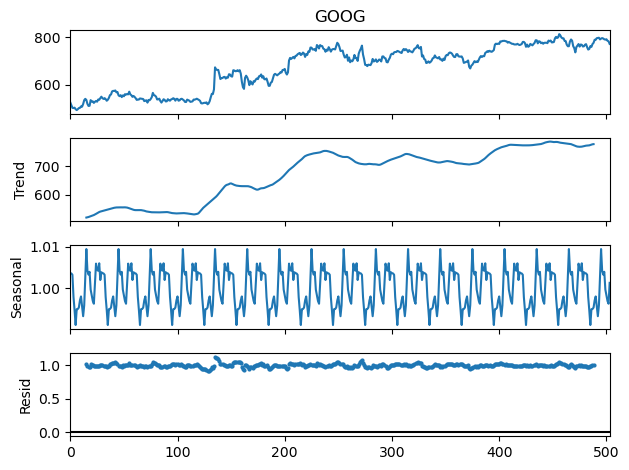

In [225]:
# FB decomposition
fb_decomp = seasonal_decompose(df['FB'], model='multiplicative', period=30)
fig  = fb_decomp.plot()
axes = fig.axes
axes[3].lines[0].set_markersize(2)
plt.show()

# GOOG decomposition
goog_decomp = seasonal_decompose(df['GOOG'], model='multiplicative', period=30)
fig = goog_decomp.plot()
axes = fig.axes
axes[3].lines[0].set_markersize(2)
plt.show()

# there is increasing trend in long term view for both stocks
# clear seasonality: triangular peaks and drops schema for FB and more irregular behaviour for GOOG
# residuals slightly oscillating around 1

## Task 9

In [226]:
fb_prices = df["FB"]

model = ARIMA(fb_prices, order=(1,1,1))
model_fit = model.fit()

forecast_steps = 10
forecast_result = model_fit.forecast(steps=forecast_steps)

print(forecast_result)

504    114.975278
505    114.975072
506    114.975072
507    114.975072
508    114.975072
509    114.975072
510    114.975072
511    114.975072
512    114.975072
513    114.975072
Name: predicted_mean, dtype: float64


## Task 10

In [227]:
model = ETS(df['GOOG'], trend='add', seasonal=None, initialization_method="estimated")

model_fit = model.fit()
forecast = model_fit.forecast(steps=10)

print(forecast)

504    772.309837
505    772.799673
506    773.289510
507    773.779346
508    774.269183
509    774.759019
510    775.248856
511    775.738692
512    776.228529
513    776.718366
dtype: float64
